# OES-32 Telemetry Triage — an executable explainer

**Kernel:** `oes32_triage_accelerator` (`oes32_triage_stream.cpp/.h`). Introduced in OES-32 HLS prototype **v0.2.0** and unchanged since. This notebook and the Python bindings were added in **0.3.0**.
**Author:** Jean-François Brisson — ORCID [0009-0000-9778-5374](https://orcid.org/0009-0000-9778-5374) — Spark AI NLP
**Cite (v0.2.0):** https://doi.org/10.5281/zenodo.23113675 · **Concept DOI (all versions):** [10.5281/zenodo.22985525](https://doi.org/10.5281/zenodo.22985525)
**Repository licence:** AGPL-3.0-only (see `LICENSE`; commercial terms in `COMMERCIAL-LICENSE.md`)

**Who this is for:** technical readers who want to see what the streaming triage kernel does, step by step, without installing Vitis HLS.

**What this notebook does**
1. Explains the conceptual framing that inspired the design and clearly separates it from what the code actually does.
2. Uses the bit-accurate Python reference model [`python/oes32_triage_ref.py`](../python/oes32_triage_ref.py) (same `ap_fixed` widths, `AP_RND` rounding, `AP_SAT` saturation), next to a floating-point golden model.
3. Runs seeded **synthetic** scenarios: steady baseline, ramp, ± spikes, shock-only burst, reset.
4. Compares the kernel with a naive fixed threshold and a *non-reverting* adaptive threshold, to show why reversion matters.
5. Replays the stimuli recorded by the real g++ testbench (`docs/evidence/triage_tau_trace.csv`) through the Python model and checks that the two agree. If the `oes32_triage` pybind11 bindings are installed, it also runs the same stimuli through the compiled C++ kernel and compares raw bits.
6. Lists the limitations.

Dependencies: `numpy`, `matplotlib`. Optional: the `oes32_triage` extension (`pip install .` from the repository root) for the C++ cross-check in §5.

## 1 · Concept: the inspiration and what is actually implemented

The author describes this design as inspired by his **theory of holographic fecundity membrane** and a broader **"law of the universe"** framing. In this notebook that framing is used **only as a metaphor**, to help explain the engineering choices:

| Metaphor | Engineering meaning in the kernel |
|---|---|
| **Membrane** | A *decision boundary*: `|x|·τ > thr` splits the stream into a **primary** channel (baseline signal) and a **residual** channel (what doesn't fit the baseline). |
| **Shocks are exceptions** | Packets flagged `is_shock` (and over-threshold packets) go to the residual channel. Shock-only packets **never change τ**, so an exception cannot *redefine what is normal*. |
| **Reversion toward sensitivity = homeostasis** | Over-threshold packets lower the gain τ (desensitise). Every nominal packet pulls τ back toward the configured set-point `tau_sensitivity`, by 1/16 of the gap. The system goes back to its reference sensitivity instead of drifting. |

<div style="border:2px solid #b00; padding:10px; border-radius:6px; background:#fff5f5">
<b>Honesty box: what this is, and what it is not</b><br>
• The kernel is <b>classical fixed-point signal triage</b>: an absolute-value multiply, a compare, a first-order (1/16) update of one gain, and a clamp. It is a standard adaptive-gain / rate-limiting gate.<br>
• The code <b>does not test, model or demonstrate</b> any physical, holographic or quantum law, nor any "law of the universe". Nothing in this notebook is evidence for such claims, and none is made.<br>
• The "membrane" vocabulary is a <b>conceptual inspiration and teaching metaphor only</b>.<br>
• All data here is <b>synthetic</b>. Vitis HLS synthesis, timing, II, resource use and on-hardware runs are <b>UNRUN</b>.
</div>

### The algorithm (from `oes32_triage_stream.cpp`)

For each packet `(x, is_shock)`, with control registers `thr` = `rate_limit_threshold`, `s` = `tau_sensitivity`, `tau_min`, `tau_max`, `reset_tau`:

```
if first call or reset_tau:  tau = clamp(s, tau_min, tau_max)
if no packet: publish tau, return
w = |x| * tau
if w > thr or is_shock:      -> residualStream ; tau -= max(w - thr, 0) >> 4   (shock-only: excess = 0)
else:                        -> primaryStream  ; tau += (s - tau) >> 4
tau = clamp(tau, tau_min, tau_max)          (computed in acc_t, then rounded once into tau_t)
```

**Fixed-point types** (all `AP_RND` = round half toward +∞, `AP_SAT` = saturate):

| Type | `ap_fixed<W,I>` | LSB | Range |
|---|---|---|---|
| `data_t` (sample) | `<18,2>` | 2⁻¹⁶ | [−2, 2−2⁻¹⁶] |
| `tau_t` (gain, τ) | `<18,4>` | 2⁻¹⁴ | [−8, 8−2⁻¹⁴] |
| `thr_t` (threshold) | `<24,6>` | 2⁻¹⁸ | [−32, 32) |
| `acc_t` (internal) | `<32,6>` | 2⁻²⁶ | [−32, 32) |

Note: only the **sample** is quantised to 2⁻¹⁶. τ is stored at 2⁻¹⁴ and the internal arithmetic runs at 2⁻²⁶. The model below copies each width exactly. `>> 4` on an `ap_fixed` is an arithmetic shift of the raw bits (it floors), and the result is rounded once when written back to `tau_t`.

## 2 · Python re-implementation (bit-accurate fixed point + float golden)

The model lives in the importable reference module `python/oes32_triage_ref.py`. It was moved out of this notebook in 0.3.0 with no change in behaviour, and the test suite checks it bit-for-bit against the compiled C++ kernel (`tests/test_triage_bitexact.py`).

Values are held as raw two's-complement integers at each type's fractional width, so all arithmetic is exact. Rounding and saturation happen only where the C++ assigns into an `ap_fixed` type. The cell below imports the module and prints the source of `FixedTriage`, so the model is still readable here.

In [1]:
import importlib.util, inspect, sys
from pathlib import Path

# Load python/oes32_triage_ref.py from this checkout (works from notebooks/ or the repo root);
# fall back to an installed copy. python/ is not put on sys.path, so the source package
# python/oes32_triage cannot shadow an installed build of the extension.
_ref_file = next((p for p in (Path("../python/oes32_triage_ref.py"), Path("python/oes32_triage_ref.py"))
                  if p.exists()), None)
if _ref_file is not None:
    _spec = importlib.util.spec_from_file_location("oes32_triage_ref", _ref_file)
    oes32_triage_ref = importlib.util.module_from_spec(_spec)
    sys.modules["oes32_triage_ref"] = oes32_triage_ref
    _spec.loader.exec_module(oes32_triage_ref)
else:
    import oes32_triage_ref

from oes32_triage_ref import (q_from_float, requant, FixedTriage, FloatTriage,
                              DATA, TAU, THR, ACC, FD, FT, FH, FA)

print(inspect.getsource(FixedTriage))

# Sanity checks of the quantiser
assert q_from_float(-2.0, *DATA) == -(1 << 17)                      # -2.0 is representable
assert q_from_float(2.0, *DATA) == (1 << 17) - 1                    # +2.0 saturates to 2 - 2^-16
assert q_from_float(0.5 / (1 << 16), *DATA) == 1                    # tie rounds toward +inf
assert q_from_float(-0.5 / (1 << 16), *DATA) == 0
print("data_t LSB = 2^-16 = %.3e | tau_t LSB = 2^-14 = %.3e | acc_t LSB = 2^-26 = %.3e"
      % (2**-16, 2**-14, 2**-26))

class FixedTriage:
    """Bit-accurate model of oes32_triage_accelerator (static state = object state)."""
    def __init__(self):
        self.tau = 1 << FT      # static tau_t adaptive_tau = 1
        self.init = False
    def _clamp(self, v_acc, lo, hi):
        lo_a, hi_a = lo << (FA - FT), hi << (FA - FT)
        if v_acc < lo_a: v_acc = lo_a
        if v_acc > hi_a: v_acc = hi_a
        return v_acc
    def step(self, thr, sens, tmin, tmax, reset, value=None, shock=False):
        thr_r = q_from_float(thr, *THR); sens_r = q_from_float(sens, *TAU)
        lo_r = q_from_float(tmin, *TAU); hi_r = q_from_float(tmax, *TAU)
        if (not self.init) or reset:
            self.tau = requant(self._clamp(sens_r << (FA - FT), lo_r, hi_r), FA, *TAU)
            self.init = True
        if value is None:
            return None, self.tau / (1 << FT)
        d = q_from_float(value, *DATA)
        mag = requant(abs(d) << (FA - FD), FA, *ACC)
        w = requant(mag * (self.tau << (FA - FT)), 

### Helper: run a stimulus list through both models

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

DEF = dict(thr=1.0, sens=1.0, tmin=0.25, tmax=4.0)

def run(stim, regs=DEF):
    # stim: list of dicts {value (None = empty call), shock, reset}
    fx, fl = FixedTriage(), FloatTriage()
    out = {k: [] for k in ("value", "shock", "reset", "route", "route_f", "tau", "tau_f")}
    for s in stim:
        args = (regs["thr"], regs["sens"], regs["tmin"], regs["tmax"], s.get("reset", False))
        r, t = fx.step(*args, value=s["value"], shock=s.get("shock", False))
        rf, tf = fl.step(*args, value=s["value"], shock=s.get("shock", False))
        out["value"].append(np.nan if s["value"] is None else q_from_float(s["value"], *DATA) / 2**16)
        out["shock"].append(bool(s.get("shock", False))); out["reset"].append(bool(s.get("reset", False)))
        out["route"].append(r or "none"); out["route_f"].append(rf or "none")
        out["tau"].append(t); out["tau_f"].append(tf)
    return {k: np.array(v) for k, v in out.items()}

## 3 · Seeded synthetic scenarios

One continuous stream (`numpy.random.default_rng(20261002)`) with default registers `thr = 1.0`, `tau_sensitivity = 1.0`, `tau_min = 0.25`, `tau_max = 4.0`:

| Segment | Samples | Content |
|---|---|---|
| A · steady baseline | 0–149 | noise around ±0.3 (σ = 0.08), random sign |
| B · ramp | 150–299 | magnitude ramps 0.3 → 1.6 |
| C · baseline with ± spikes | 300–499 | baseline plus a spike every 25 samples, alternating ±1.5 / ±1.95 |
| D · shock-only burst | 500–539 | small samples (\|x\| ≈ 0.1) flagged `is_shock = 1` |
| E · recovery | 540–619 | baseline, with a short ±1.8 overload at 600–609 |
| F · reset | 620 | one empty call with `reset_tau = 1`, after the overload has pulled τ down |
| G · baseline | 621–720 | baseline |

In [3]:
rng = np.random.default_rng(20261002)
def baseline(n):
    return list(rng.choice([-1, 1], n) * np.abs(0.3 + 0.08 * rng.standard_normal(n)))

stim, seg = [], {}
def add(name, vals, shock=False):
    seg[name] = (len(stim), len(stim) + len(vals))
    stim.extend(dict(value=float(v), shock=shock) for v in vals)

add("A baseline", baseline(150))
add("B ramp", list(np.linspace(0.3, 1.6, 150) * rng.choice([-1, 1], 150)))
c = baseline(200)
for j, i in enumerate(range(12, 200, 25)):
    c[i] = [1.5, -1.5, 1.95, -1.95][j % 4]
add("C spikes", c)
add("D shock burst", list(0.1 * np.where(np.arange(40) % 2, -1, 1)), shock=True)
e = baseline(80)
e[60:70] = [1.8 * (-1) ** k for k in range(10)]           # short overload to pull tau down before the reset
add("E recovery", e)
seg["F reset"] = (len(stim), len(stim) + 1); stim.append(dict(value=None, reset=True))
add("G baseline", baseline(100))

R = run(stim)
n = len(stim); t = np.arange(n)
pk = ~np.isnan(R["value"])
print(f"{n} calls, {pk.sum()} packets: primary={np.sum(R['route']=='primary')}, residual={np.sum(R['route']=='residual')}")
print(f"routing fixed vs float golden: mismatches = {np.sum(R['route'] != R['route_f'])}")
print(f"max |tau_fixed - tau_float| = {np.max(np.abs(R['tau']-R['tau_f'])):.3e}  "
      f"({np.max(np.abs(R['tau']-R['tau_f']))/2**-14:.1f} LSB of tau_t)")
print()
print(f"{'segment':22s} {'packets':>7s} {'residual':>8s} {'tau min':>8s} {'tau end':>8s}")
for k, (a, b) in seg.items():
    m = pk[a:b]
    print(f"{k:22s} {m.sum():7d} {np.sum(R['route'][a:b]=='residual'):8d} "
          f"{R['tau'][a:b].min():8.4f} {R['tau'][b-1]:8.4f}")

721 calls, 720 packets: primary=593, residual=127
routing fixed vs float golden: mismatches = 0
max |tau_fixed - tau_float| = 1.953e-04  (3.2 LSB of tau_t)

segment                packets residual  tau min  tau end
A baseline                 150        0   1.0000   1.0000
B ramp                     150       69   0.6622   0.6622
C spikes                   200        8   0.6833   0.9670
D shock burst               40       40   0.9670   0.9670
E recovery                  80       10   0.6901   0.8375
F reset                      0        0   1.0000   1.0000
G baseline                 100        0   1.0000   1.0000


### Signal with primary / residual colouring, and τ over time

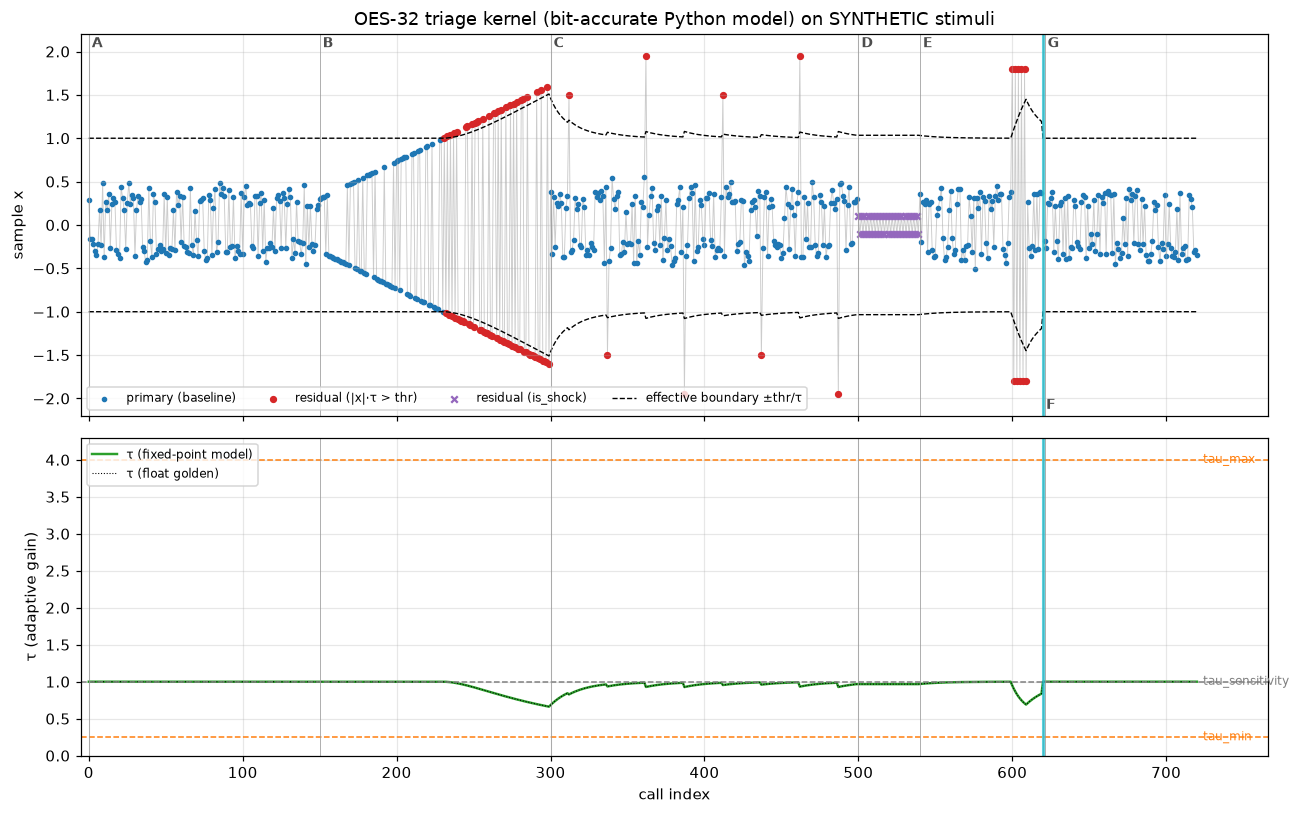

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
prim = R["route"] == "primary"; res = (R["route"] == "residual") & ~R["shock"]; shk = R["shock"]
ax1.plot(t, R["value"], color="0.8", lw=0.6, zorder=0)
ax1.scatter(t[prim], R["value"][prim], s=7, c="tab:blue", label="primary (baseline)")
ax1.scatter(t[res], R["value"][res], s=14, c="tab:red", label="residual (|x|·τ > thr)")
ax1.scatter(t[shk], R["value"][shk], s=18, marker="x", c="tab:purple", label="residual (is_shock)")
eff = DEF["thr"] / R["tau"]
ax1.plot(t, eff, "k--", lw=0.9, label="effective boundary ±thr/τ"); ax1.plot(t, -eff, "k--", lw=0.9)
ax1.set_ylabel("sample x"); ax1.set_ylim(-2.2, 2.2)
ax1.set_title("OES-32 triage kernel (bit-accurate Python model) on SYNTHETIC stimuli")
ax2.plot(t, R["tau"], c="tab:green", lw=1.6, label="τ (fixed-point model)")
ax2.plot(t, R["tau_f"], c="k", lw=0.7, ls=":", label="τ (float golden)")
for y, lab, col in [(DEF["tmin"], "tau_min", "tab:orange"), (DEF["tmax"], "tau_max", "tab:orange"),
                    (DEF["sens"], "tau_sensitivity", "tab:gray")]:
    ax2.axhline(y, ls="--", c=col, lw=1); ax2.text(n + 3, y, lab, va="center", fontsize=8, color=col)
ax2.set_ylabel("τ (adaptive gain)"); ax2.set_xlabel("call index"); ax2.set_ylim(0, 4.3)
for ax in (ax1, ax2):
    for k, (a, b) in seg.items():
        ax.axvline(a, c="0.6", lw=0.5)
        if ax is ax1: ax.text(a + 2, 2.05 if k[0] != "F" else -2.12, k.split()[0], fontsize=9, color="0.3", weight="bold")
    ax.axvline(seg["F reset"][0], c="tab:cyan", lw=2, alpha=0.7)
ax1.legend(loc="lower left", fontsize=8, ncol=4); ax2.legend(loc="upper left", fontsize=8)
ax2.set_xlim(-5, n + 45)
plt.tight_layout(); plt.show()

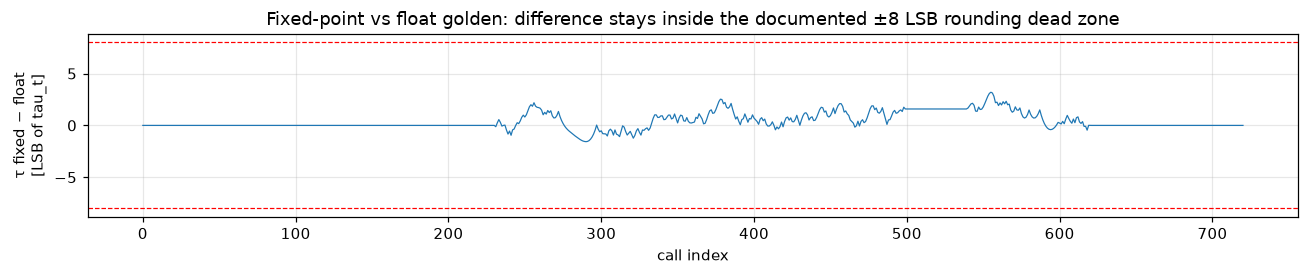

In [5]:
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(t, (R["tau"] - R["tau_f"]) / 2**-14, lw=0.8)
ax.axhline(8, ls="--", c="r", lw=0.8); ax.axhline(-8, ls="--", c="r", lw=0.8)
ax.set_ylabel("τ fixed − float\n[LSB of tau_t]"); ax.set_xlabel("call index")
ax.set_title("Fixed-point vs float golden: difference stays inside the documented ±8 LSB rounding dead zone")
plt.tight_layout(); plt.show()

**Reading the plots**

* **Baseline (A, G):** |x|·τ stays below `thr`, so everything goes to primary and τ sits at `tau_sensitivity`.
* **Ramp (B):** once |x|·τ > thr, samples go to residual and τ falls (down to ≈ 0.66 here). That raises the effective boundary `thr/τ`, which follows just below the rising ramp. In this run all 69 ramp samples above |x| = 1 go to residual, because the ramp keeps climbing past the boundary. On a *flat* overload the boundary catches up with the signal and some samples leak back to primary (see §4).
* **Spikes (C):** each spike (positive or negative, including −1.95) goes to residual and briefly lowers τ. τ then **recovers** geometrically (×15/16 per nominal packet) back toward `tau_sensitivity`.
* **Shock-only burst (D):** all flagged packets go to residual and **τ stays flat**. Exceptions do not redefine normal.
* **Reset (F):** a short overload pulls τ down, and a single `reset_tau` call reloads τ = clamp(`tau_sensitivity`).
* **Fixed vs float:** routing is identical here. The τ difference is a few LSB, from the relaxation dead zone documented in `docs/TRIAGE_STREAM_DESIGN.md` §4: once |s − τ| < 8 LSB, `(s − τ) >> 4` rounds to zero.

## 4 · Why reversion matters: comparison with two simpler detectors

Test signal (seeded, synthetic): baseline (|x| ≈ 0.5), then a **sustained 120-sample overload** at |x| ≈ 1.6 (a "shock regime"), then baseline again with **moderate anomalies** of |x| = 1.25 injected every 20 samples. These are the events we want to keep catching after the shock regime ends.

Detectors, all with `thr = 1.0`:
1. **Naive fixed threshold:** residual iff |x| > 1.0. No state.
2. **Non-reverting adaptive threshold:** the same kernel *without* the reversion term. τ can only go down (a ratchet), so once a shock lowers the gain it never comes back.
3. **OES-32 kernel (reverting):** the bit-accurate model above.

For 2 and 3 we plot the effective boundary `thr/τ` in signal units.

In [6]:
class NonRevertingTriage(FixedTriage):
    # Identical to the kernel except the primary path does NOT relax tau toward tau_sensitivity.
    def step(self, thr, sens, tmin, tmax, reset, value=None, shock=False):
        tau_before = self.tau
        route, tau = super().step(thr, sens, tmin, tmax, reset, value, shock)
        if route == "primary":
            self.tau = tau_before           # undo reversion: ratchet (only decreases on residual)
        return route, self.tau / (1 << FT)

rng2 = np.random.default_rng(7)
nb_, ns_, na_ = 150, 120, 300
base = lambda k: rng2.choice([-1, 1], k) * np.abs(0.5 + 0.08 * rng2.standard_normal(k))
x = np.concatenate([base(nb_),
                    rng2.choice([-1, 1], ns_) * (1.6 + 0.05 * rng2.standard_normal(ns_)),
                    base(na_)])
anom_idx = np.arange(nb_ + ns_ + 20, len(x), 20)
x[anom_idx] = 1.25 * rng2.choice([-1, 1], len(anom_idx))
x = np.array([q_from_float(v, *DATA) / 2**16 for v in x])
is_anom = np.zeros(len(x), bool); is_anom[anom_idx] = True
post = np.arange(len(x)) >= nb_ + ns_
shock_reg = (np.arange(len(x)) >= nb_) & ~post

def drive(model):
    routes, taus = [], []
    for v in x:
        r_, t_ = model.step(DEF["thr"], DEF["sens"], DEF["tmin"], DEF["tmax"], False, value=float(v))
        routes.append(r_ == "residual"); taus.append(t_)
    return np.array(routes), np.array(taus)

det = {}
det["naive fixed |x|>thr"] = (np.abs(x) > DEF["thr"], np.full(len(x), DEF["thr"]))
r_nr, tau_nr = drive(NonRevertingTriage()); det["non-reverting adaptive"] = (r_nr, DEF["thr"] / tau_nr)
r_k, tau_k = drive(FixedTriage());         det["OES-32 kernel (reverting)"] = (r_k, DEF["thr"] / tau_k)

print(f"{'detector':28s} {'shock-regime residual':>22s} {'post-shock anomaly recall':>26s} {'post-shock baseline FP':>23s} {'boundary at end':>16s}")
summary = {}
for name, (flag, b) in det.items():
    sr = flag[shock_reg].mean(); rec = flag[is_anom].mean(); fp = flag[post & ~is_anom].mean()
    summary[name] = (sr, rec, fp, b[-1])
    print(f"{name:28s} {sr:22.1%} {f'{flag[is_anom].sum()}/{is_anom.sum()} = {rec:.0%}':>26s} {fp:23.1%} {b[-1]:16.3f}")

detector                      shock-regime residual  post-shock anomaly recall  post-shock baseline FP  boundary at end
naive fixed |x|>thr                          100.0%               14/14 = 100%                    0.0%            1.000
non-reverting adaptive                        44.2%                  0/14 = 0%                    0.0%            1.652
OES-32 kernel (reverting)                     90.0%               14/14 = 100%                    0.0%            1.006


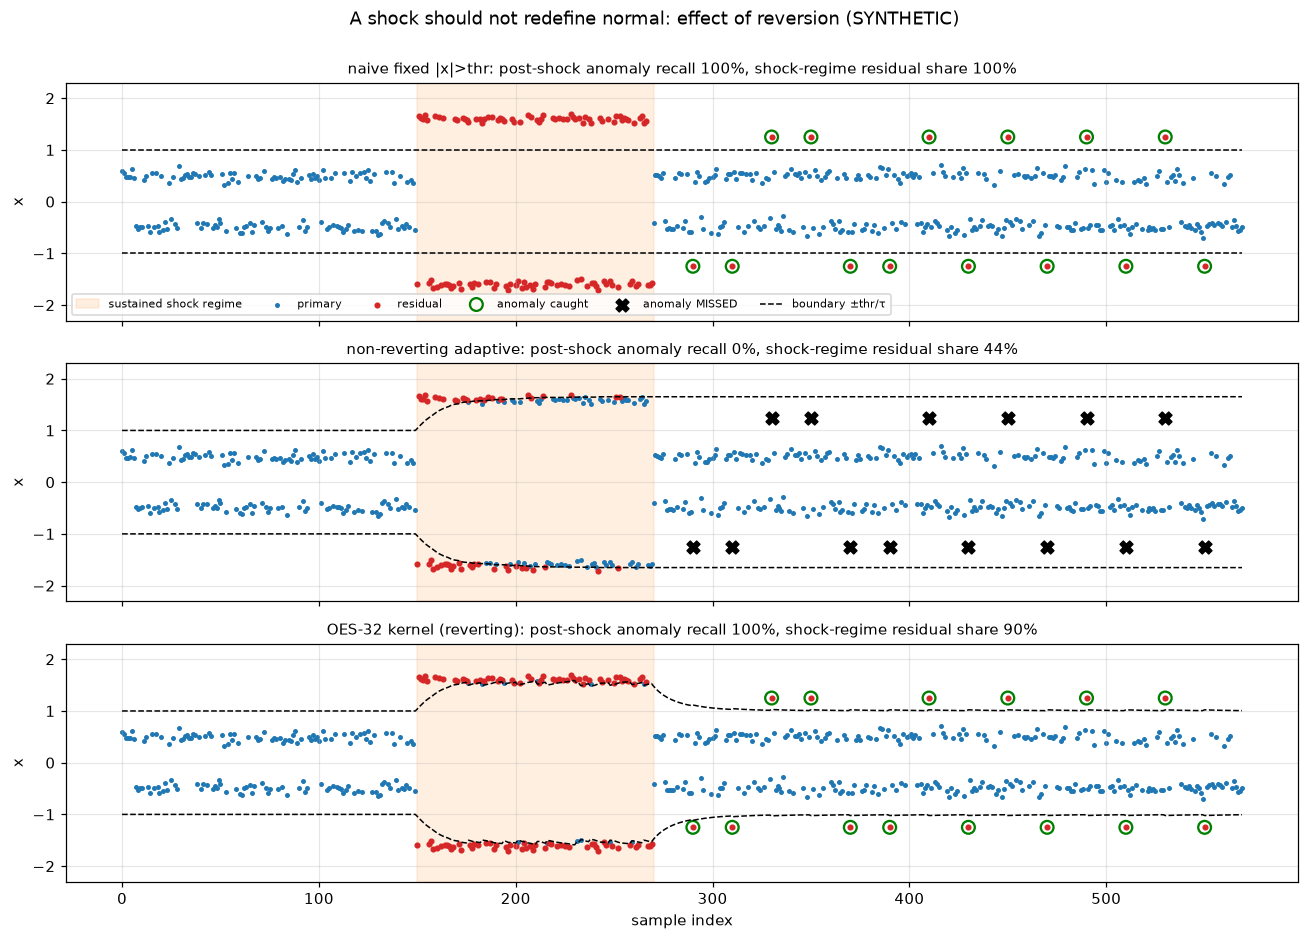

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)
tt = np.arange(len(x))
for ax, (name, (flag, b)) in zip(axes, det.items()):
    ax.axvspan(nb_, nb_ + ns_, color="tab:orange", alpha=0.12, label="sustained shock regime")
    ax.scatter(tt[~flag], x[~flag], s=5, c="tab:blue", label="primary")
    ax.scatter(tt[flag], x[flag], s=9, c="tab:red", label="residual")
    miss = is_anom & ~flag
    ax.scatter(tt[is_anom & flag], x[is_anom & flag], s=70, facecolors="none", edgecolors="g", lw=1.5, label="anomaly caught")
    ax.scatter(tt[miss], x[miss], s=70, marker="X", c="k", label="anomaly MISSED")
    ax.plot(tt, b, "k--", lw=1); ax.plot(tt, -b, "k--", lw=1, label="boundary ±thr/τ")
    sr, rec, fp, _ = summary[name]
    ax.set_title(f"{name}: post-shock anomaly recall {rec:.0%}, shock-regime residual share {sr:.0%}", fontsize=10)
    ax.set_ylim(-2.3, 2.3); ax.set_ylabel("x")
axes[0].legend(fontsize=7.5, ncol=6, loc="lower left"); axes[-1].set_xlabel("sample index")
plt.suptitle("A shock should not redefine normal: effect of reversion (SYNTHETIC)", y=1.0)
plt.tight_layout(); plt.show()

**Takeaways**

* The **naive fixed threshold** catches the post-shock anomalies, but it has no memory. During the sustained shock regime it sends ~100 % of samples to residual (no rate limiting), and it can't express "this regime is abnormal" in any state.
* The **non-reverting adaptive threshold** desensitises during the shock regime and then **stays desensitised**. The shock has *redefined normal*: the boundary stays near |x| ≈ 1.6 and every post-shock 1.25 anomaly is missed.
* The **OES-32 kernel** desensitises during the shock: the boundary rises to the overload level, and about 10 % of overload samples sit on the boundary and pass to primary, which gives mild rate limiting. It then **reverts toward `tau_sensitivity`** within a few tens of nominal packets (time constant ≈ 16 packets). The post-shock anomalies are caught again.

This is the engineering content of the "homeostasis" metaphor. It is ordinary first-order adaptive-gain control, nothing more.

## 5 · Agreement with the real g++ testbench (`docs/evidence/triage_tau_trace.csv`)

The v0.2.0 g++ testbench (`test_oes32_triage.cpp`, run against the actual C++ kernel with the open-source Xilinx `ap_fixed` headers) logged every call: stimulus, register values, route and τ for the fixed kernel and its double golden. Here we **replay the exact same stimuli and registers** through the Python model and compare.

In [8]:
import csv
from pathlib import Path
cands = [Path("../docs/evidence/triage_tau_trace.csv"), Path("docs/evidence/triage_tau_trace.csv"),
         Path("oes32-hls/docs/evidence/triage_tau_trace.csv")]
csv_path = next((p for p in cands if p.exists()), None)
if csv_path is None:
    print("Evidence CSV not found; skipping section 5.")
    E = None
else:
    rows = list(csv.DictReader(l for l in open(csv_path) if not l.startswith("#")))
    fx, fl = FixedTriage(), FloatTriage()
    E = {k: [] for k in ("tau_cpp", "tau_py", "tau_gold_cpp", "tau_gold_py", "scen")}
    route_mm = 0; route_g_mm = 0
    for r in rows:
        args = (float(r["rate_limit_threshold"]), float(r["tau_sensitivity"]), float(r["tau_min"]),
                float(r["tau_max"]), r["reset_tau"] == "1")
        v = float(r["value"]) if r["has_packet"] == "1" else None
        sh = r["is_shock"] == "1"
        a, tp = fx.step(*args, value=v, shock=sh); b, tg = fl.step(*args, value=v, shock=sh)
        route_mm += (a or "none") != r["route_fixed"]; route_g_mm += (b or "none") != r["route_golden"]
        E["tau_cpp"].append(float(r["tau_fixed"])); E["tau_py"].append(tp)
        E["tau_gold_cpp"].append(float(r["tau_golden"])); E["tau_gold_py"].append(tg); E["scen"].append(r["scenario"])
    E = {k: np.array(v) for k, v in E.items()}
    d = np.abs(E["tau_py"] - E["tau_cpp"])
    print(f"rows replayed: {len(rows)}  (packets: {sum(r['has_packet']=='1' for r in rows)})")
    print(f"routing mismatches  Python fixed vs C++ kernel : {route_mm}")
    print(f"routing mismatches  Python float vs C++ golden : {route_g_mm}")
    print(f"tau: max |Python fixed - C++ kernel| = {d.max():.2e}  (CSV prints 8 decimals; tau_t LSB = {2**-14:.2e})")
    print(f"tau: rows bit-identical after re-quantising CSV to tau_t: "
          f"{np.sum(np.round(E['tau_cpp']*2**14) == np.round(E['tau_py']*2**14))}/{len(rows)}")
    print(f"tau: max |Python float - C++ golden| = {np.max(np.abs(E['tau_gold_py']-E['tau_gold_cpp'])):.2e}")
    print(f"tau: max |C++ kernel - C++ golden| = {np.max(np.abs(E['tau_cpp']-E['tau_gold_cpp'])):.3e} "
          f"(testbench log reports 4.272e-04)")

rows replayed: 1411  (packets: 1402)
routing mismatches  Python fixed vs C++ kernel : 0
routing mismatches  Python float vs C++ golden : 0
tau: max |Python fixed - C++ kernel| = 5.00e-09  (CSV prints 8 decimals; tau_t LSB = 6.10e-05)
tau: rows bit-identical after re-quantising CSV to tau_t: 1411/1411
tau: max |Python float - C++ golden| = 5.00e-09
tau: max |C++ kernel - C++ golden| = 4.272e-04 (testbench log reports 4.272e-04)


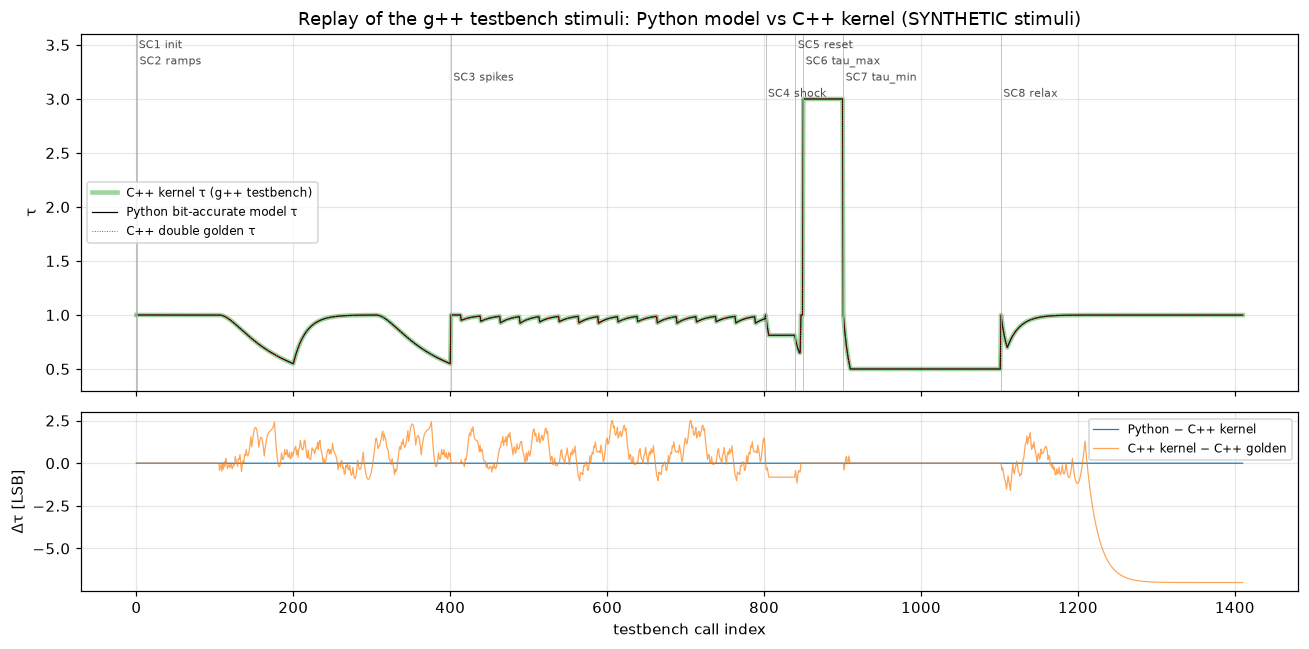

In [9]:
if E is not None:
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
    k = np.arange(len(E["tau_cpp"]))
    a1.plot(k, E["tau_cpp"], c="tab:green", lw=3, alpha=0.45, label="C++ kernel τ (g++ testbench)")
    a1.plot(k, E["tau_py"], c="k", lw=0.8, label="Python bit-accurate model τ")
    a1.plot(k, E["tau_gold_cpp"], c="tab:red", lw=0.6, ls=":", label="C++ double golden τ")
    grp = {"init": "SC1 init", "ramp": "SC2 ramps", "spike": "SC3 spikes", "spikes": "SC3 spikes",
           "shock": "SC4 shock", "reset": "SC5 reset", "clamp_max": "SC6 tau_max", "clamp_min": "SC7 tau_min",
           "relax": "SC8 relax"}
    prev, j = None, 0
    for i, s in enumerate(E["scen"]):
        g = grp.get(s if s.startswith("clamp") else s.split("_")[0], s)
        if g != prev:
            a1.axvline(i, c="0.7", lw=0.5)
            a1.text(i + 3, 3.47 - 0.15 * (j % 4), g, fontsize=7.5, color="0.3"); j += 1
            prev = g
    a1.set_ylim(0.3, 3.6)
    a1.set_ylabel("τ"); a1.legend(fontsize=8, loc="center left")
    a1.set_title("Replay of the g++ testbench stimuli: Python model vs C++ kernel (SYNTHETIC stimuli)")
    a2.plot(k, (E["tau_py"] - E["tau_cpp"]) / 2**-14, lw=0.8, label="Python − C++ kernel")
    a2.plot(k, (E["tau_cpp"] - E["tau_gold_cpp"]) / 2**-14, lw=0.8, alpha=0.7, label="C++ kernel − C++ golden")
    a2.set_ylabel("Δτ [LSB]"); a2.set_xlabel("testbench call index"); a2.legend(fontsize=8)
    plt.tight_layout(); plt.show()

The Python model reproduces the C++ kernel **bit-for-bit** on every logged call: identical routing, and identical τ once the 8-decimal CSV values are re-quantised to `tau_t`. The fixed-vs-golden τ gap (≤ 7 LSB ≈ 4.27e-4) is the documented relaxation dead zone, and it is inside the testbench's 16-LSB tolerance.

What this shows: the Python description of the algorithm matches the C++ source *as compiled by g++ with the `ap_fixed` headers*. It says nothing about the synthesised RTL (see below).

### 5b · Optional: the same stimuli through the compiled C++ kernel (pybind11)

`oes32_triage.TriageKernel` runs the **real** `oes32_triage_stream.cpp`, compiled unchanged into a Python extension, against the same pinned `ap_*` headers. The cell below replays every testbench row through it and through the Python reference model, and compares the raw `tau_t` bits directly, with no CSV rounding involved. If the extension isn't installed, the cell says so and skips.

This is still a **C-simulation** of the HLS source. It is not synthesised RTL.

In [10]:
try:
    import oes32_triage
    from oes32_triage import TriageKernel
except ImportError as exc:
    oes32_triage = None
    print(f"oes32_triage extension not installed ({exc}); skipping the C++ cross-check.")

if oes32_triage is not None and E is not None:
    k, fx = TriageKernel(), FixedTriage()
    route_mm = bits_mm = 0
    for r in rows:
        v = float(r["value"]) if r["has_packet"] == "1" else None
        regs = dict(rate_limit_threshold=float(r["rate_limit_threshold"]),
                    tau_sensitivity=float(r["tau_sensitivity"]),
                    tau_min=float(r["tau_min"]), tau_max=float(r["tau_max"]))
        route_cpp, _ = k.step(v, is_shock=r["is_shock"] == "1", reset_tau=r["reset_tau"] == "1", **regs)
        route_py, _ = fx.step(regs["rate_limit_threshold"], regs["tau_sensitivity"], regs["tau_min"],
                              regs["tau_max"], r["reset_tau"] == "1", value=v, shock=r["is_shock"] == "1")
        route_mm += route_cpp != route_py
        bits_mm += k.tau_raw != fx.tau
    print(f"oes32_triage {oes32_triage.__version__}: {len(rows)} calls replayed through the compiled C++ kernel")
    print(f"routing mismatches  C++ (pybind) vs Python fixed model : {route_mm}")
    print(f"tau_t raw-bit mismatches                               : {bits_mm}")
    assert route_mm == 0 and bits_mm == 0

oes32_triage 0.3.0: 1411 calls replayed through the compiled C++ kernel
routing mismatches  C++ (pybind) vs Python fixed model : 0
tau_t raw-bit mismatches                               : 0


## 6 · Limitations

* **Synthetic data only.** Every stimulus here and in the testbench is generated (seeded noise, ramps, spikes, flagged bursts). No real telemetry has been processed.
* **Synthesis and hardware: UNRUN.** No Vitis HLS synthesis, C/RTL co-simulation, timing closure, II, latency or resource figures exist for this kernel, and nothing has run on the ZCU111 target (`xczu28dr`). Agreement with g++ is a *C-simulation* result only.
* **Per-call / `ap_ctrl_none` design.** The kernel reads at most one packet per invocation (`read_nb`) and relies on continuous re-invocation. Whether this yields a free-running II = 1 core is unknown until a synthesis report exists (see `docs/TRIAGE_STREAM_DESIGN.md` §5).
* **Rounding dead zone.** τ can settle up to 8 LSB of `tau_t` (≈ 4.9e-4) away from `tau_sensitivity` (documented, bounded).
* **Parameters not tuned.** `thr`, `tau_sensitivity`, the 1/16 rates and the clamp bounds are illustrative defaults, not calibrated on any application.
* **Comparison detectors are simple strawmen** built to isolate the effect of reversion, not to benchmark against state-of-the-art anomaly detectors.
* **Conceptual framing.** The "holographic fecundity membrane" / "law of the universe" language is the author's inspiration and metaphor. The code does not test or demonstrate any physical, holographic or quantum law.

---
*Cite:* Brisson, J.-F. *OES-32 HLS Prototype* v0.2.0. Zenodo. https://doi.org/10.5281/zenodo.23113675 (concept DOI: https://doi.org/10.5281/zenodo.22985525).